
#House Price Prediction — ML Regression Models

**NAME:** Aditya Tiwari | MCA Student

**EMAIL:** Adityatiwari2211@gmail.com

**DATASET:** House Prices - Advanced Regression Techniques (Kaggle)

**TOOLS:** Python, Scikit-learn, Pandas, NumPy, Matplotlib, Seaborn

In [31]:
import pandas as pd

url = "https://raw.githubusercontent.com/Gabbargod/train-houseprice/refs/heads/main/train.csv"

df = pd.read_csv(url)

print(df.shape)

(1460, 81)


## STEP 1 — Load, Explore & Preprocess

In [32]:
# CELL 1 — IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import LinearRegression
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
sns.set_theme(style="whitegrid")
print("Libraries ready")

Libraries ready


In [33]:
# CELL 2 — LOAD DATA
df = pd.read_csv('https://raw.githubusercontent.com/Gabbargod/train-houseprice/refs/heads/main/train.csv')
print("Shape:", df.shape)
print(df['SalePrice'].describe())
df.head()

Shape: (1460, 81)
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [34]:
# CELL 3 — MISSING VALUES
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

PoolQC          99.52
MiscFeature     96.30
Alley           93.77
Fence           80.75
MasVnrType      59.73
FireplaceQu     47.26
LotFrontage     17.74
GarageType       5.55
GarageYrBlt      5.55
GarageFinish     5.55
GarageQual       5.55
GarageCond       5.55
BsmtExposure     2.60
BsmtFinType2     2.60
BsmtQual         2.53
BsmtCond         2.53
BsmtFinType1     2.53
MasVnrArea       0.55
Electrical       0.07
dtype: float64


In [35]:
# CELL 4 — CLEAN & PREPROCESS
df2 = df.copy()
# Drop high-missing columns (>40%)
drop_cols = missing_pct[missing_pct > 40].index.tolist()
df2.drop(columns=drop_cols + ['Id'], inplace=True, errors='ignore')
# Fill numeric with median
for col in df2.select_dtypes(include=[np.number]).columns:
    df2[col].fillna(df2[col].median(), inplace=True)
# Fill categorical with mode
for col in df2.select_dtypes(include='object').columns:
    df2[col].fillna(df2[col].mode()[0], inplace=True)
print("After cleaning:", df2.shape)
print("Nulls remaining:", df2.isnull().sum().sum())

After cleaning: (1460, 74)
Nulls remaining: 0


## STEP 2 — Feature Engineering


Top 15 features correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
GarageYrBlt     0.466754
BsmtFinSF1      0.386420
LotFrontage     0.334771
Name: SalePrice, dtype: float64


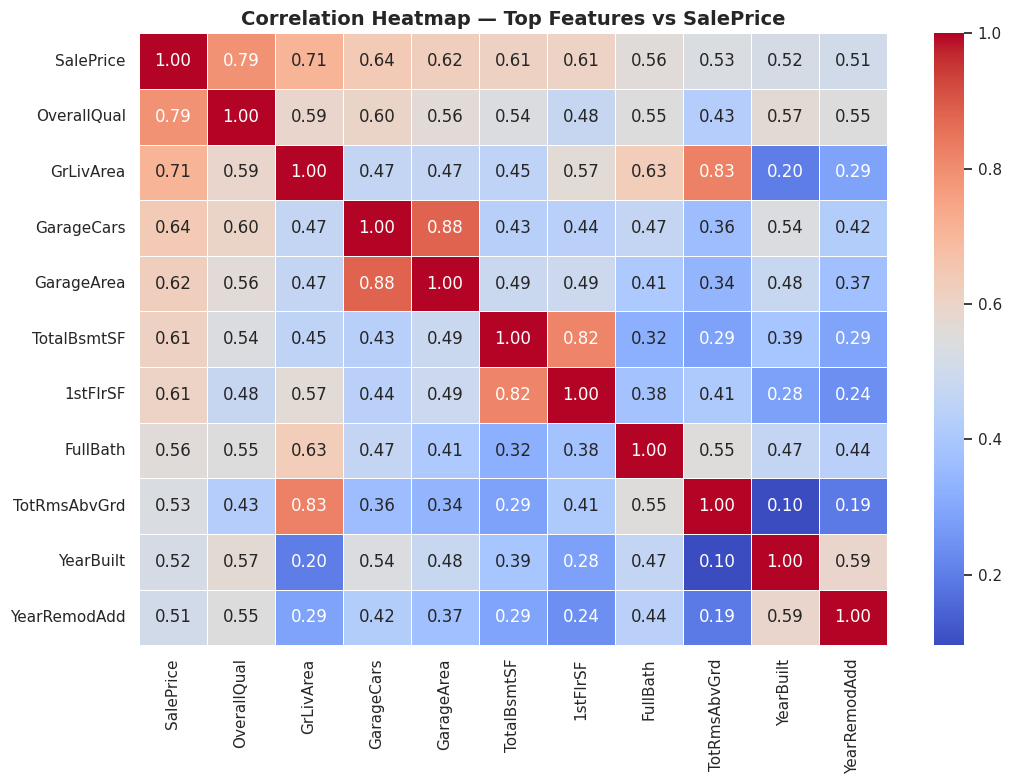

In [36]:
# CELL 5 — CORRELATION ANALYSIS
num_df = df2.select_dtypes(include=[np.number])
corr   = num_df.corr()['SalePrice'].abs().sort_values(ascending=False)
print("Top 15 features correlated with SalePrice:")
print(corr.head(16))

# Heatmap of top 10
top10 = corr.head(11).index.tolist()
fig, ax = plt.subplots(figsize=(11,8))
sns.heatmap(num_df[top10].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Top Features vs SalePrice',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('p2_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [37]:
# CELL 6 — FEATURE SELECTION & ENCODING
top_num = [f for f in corr.head(11).index if f != 'SalePrice']
cat_feats = [c for c in ['Neighborhood','ExterQual','KitchenQual','BsmtQual','GarageFinish']
             if c in df2.columns]
all_feats = top_num + cat_feats

df_model = df2[all_feats + ['SalePrice']].copy()
le = LabelEncoder()
for col in cat_feats:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Features used:", all_feats)
print("Model data shape:", df_model.shape)


Features used: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish']
Model data shape: (1460, 16)


## STEP 3 — Train 3 Models


In [38]:
# CELL 7 — TRAIN/TEST SPLIT
X = df_model.drop('SalePrice', axis=1)
y = df_model['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (1168, 15) | Test: (292, 15)


In [39]:
# CELL 8 — MODEL 1: LINEAR REGRESSION
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
yp_lr = lr.predict(X_test_sc)
rmse_lr = np.sqrt(mean_squared_error(y_test, yp_lr))
mae_lr  = mean_absolute_error(y_test, yp_lr)
r2_lr   = r2_score(y_test, yp_lr)
print(f"Linear Regression → RMSE:{rmse_lr:,.0f}  MAE:{mae_lr:,.0f}  R²:{r2_lr:.4f}")


Linear Regression → RMSE:37,148  MAE:23,572  R²:0.8201


In [40]:
# CELL 9 — MODEL 2: DECISION TREE
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
yp_dt = dt.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, yp_dt))
mae_dt  = mean_absolute_error(y_test, yp_dt)
r2_dt   = r2_score(y_test, yp_dt)
print(f"Decision Tree     → RMSE:{rmse_dt:,.0f}  MAE:{mae_dt:,.0f}  R²:{r2_dt:.4f}")


Decision Tree     → RMSE:38,532  MAE:23,997  R²:0.8064


In [41]:
# CELL 10 — MODEL 3: RANDOM FOREST
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
yp_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, yp_rf))
mae_rf  = mean_absolute_error(y_test, yp_rf)
r2_rf   = r2_score(y_test, yp_rf)
print(f"Random Forest     → RMSE:{rmse_rf:,.0f}  MAE:{mae_rf:,.0f}  R²:{r2_rf:.4f}")


Random Forest     → RMSE:29,056  MAE:18,321  R²:0.8899


## STEP 4 — Comparison Table + Evaluation



         MODEL COMPARISON TABLE
            Model  RMSE ($)  MAE ($)  R² Score
Linear Regression  37148.21 23571.71    0.8201
    Decision Tree  38532.37 23997.48    0.8064
    Random Forest  29056.04 18321.16    0.8899

BEST MODEL: Random Forest


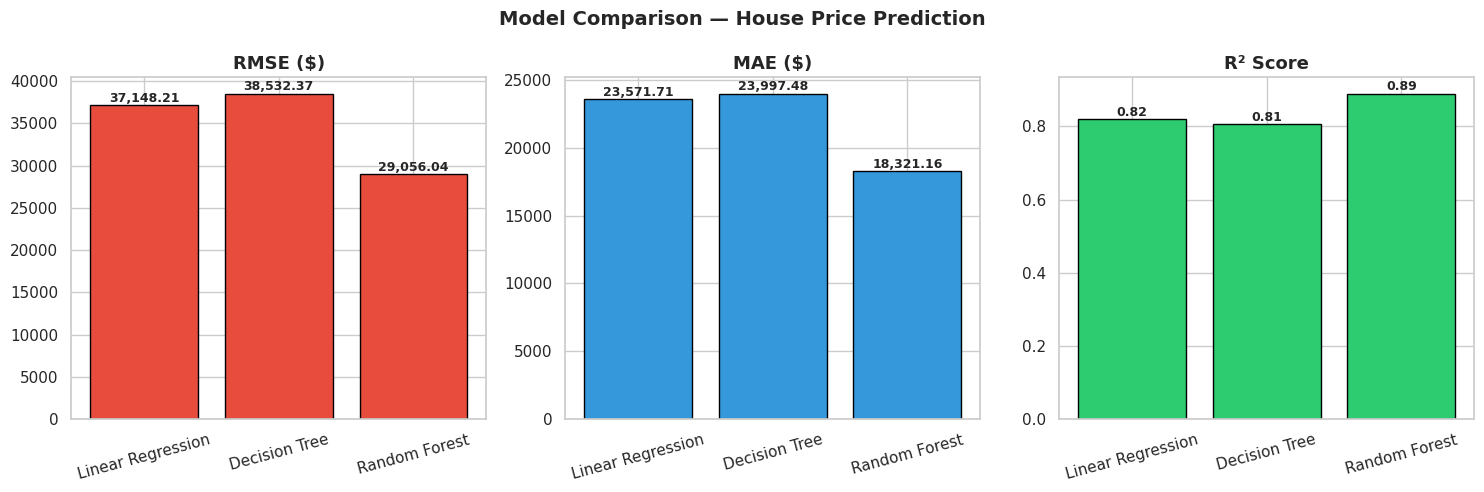

In [42]:
# CELL 11 — COMPARISON TABLE
results = pd.DataFrame({
    'Model'   : ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'RMSE ($)': [round(rmse_lr,2), round(rmse_dt,2), round(rmse_rf,2)],
    'MAE ($)' : [round(mae_lr,2),  round(mae_dt,2),  round(mae_rf,2)],
    'R² Score': [round(r2_lr,4),   round(r2_dt,4),   round(r2_rf,4)]
})
print("\n" + "="*60)
print("         MODEL COMPARISON TABLE")
print("="*60)
print(results.to_string(index=False))
print("="*60)
print(f"\nBEST MODEL: {results.loc[results['R² Score'].idxmax(),'Model']}")

# Bar chart comparison
fig, axes = plt.subplots(1,3,figsize=(15,5))
for ax, metric, color in zip(axes,['RMSE ($)','MAE ($)','R² Score'],['#E74C3C','#3498DB','#2ECC71']):
    bars = ax.bar(results['Model'], results[metric], color=color, edgecolor='black')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h*1.01, f'{h:,.2f}',
                ha='center', fontsize=9, fontweight='bold')
plt.suptitle('Model Comparison — House Price Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('p2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


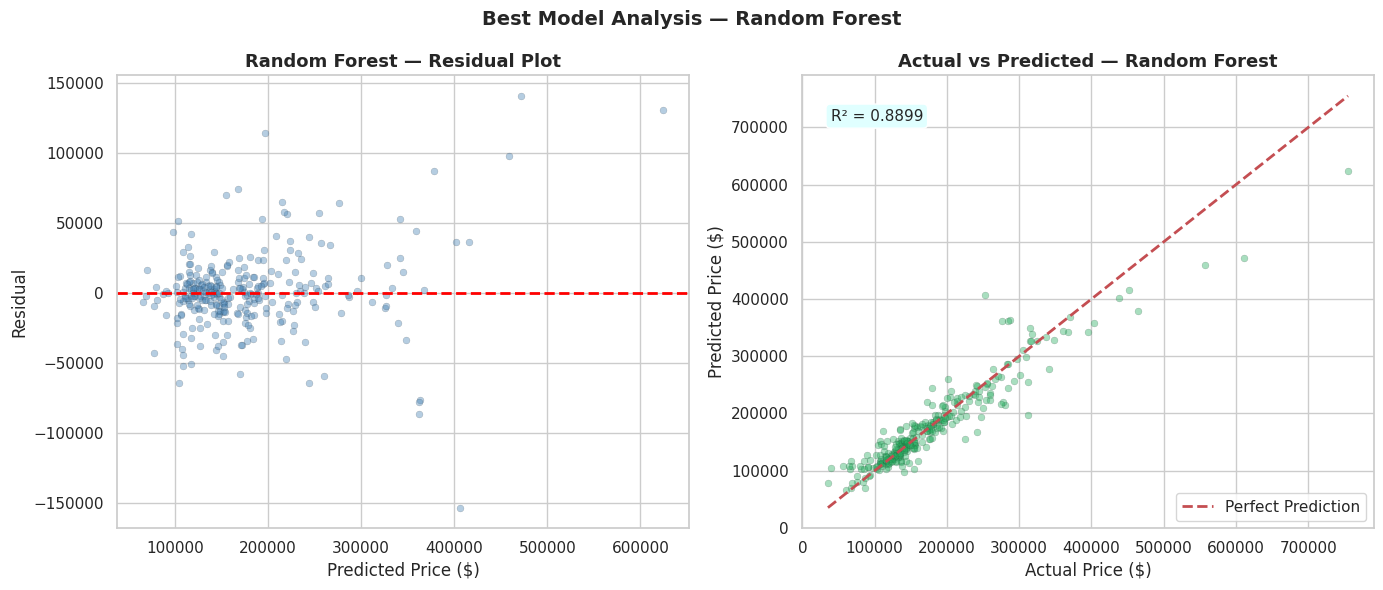

In [43]:
# CELL 12 — RESIDUAL PLOT (Random Forest)
residuals = y_test - yp_rf
fig, axes = plt.subplots(1,2,figsize=(14,6))

axes[0].scatter(yp_rf, residuals, alpha=0.4, color='steelblue', edgecolor='k', linewidth=0.2, s=25)
axes[0].axhline(0, color='red', linewidth=2, linestyle='--')
axes[0].set_title('Random Forest — Residual Plot', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Price ($)'); axes[0].set_ylabel('Residual')

mv = min(y_test.min(), yp_rf.min()); xv = max(y_test.max(), yp_rf.max())
axes[1].scatter(y_test, yp_rf, alpha=0.4, color='#27AE60', edgecolor='k', linewidth=0.2, s=25)
axes[1].plot([mv,xv],[mv,xv],'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted — Random Forest', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual Price ($)'); axes[1].set_ylabel('Predicted Price ($)')
axes[1].legend()
axes[1].text(0.05, 0.9, f'R² = {r2_rf:.4f}', transform=axes[1].transAxes,
             fontsize=11, bbox=dict(boxstyle='round', facecolor='lightcyan'))

plt.suptitle('Best Model Analysis — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('p2_residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()


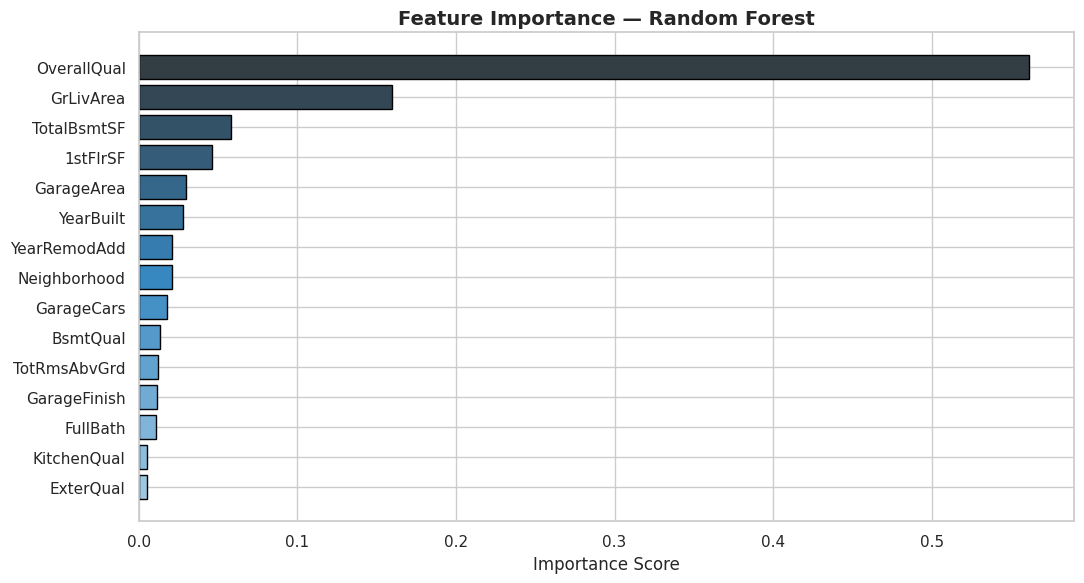

In [44]:
# CELL 13 — FEATURE IMPORTANCE
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11,6))
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
        color=sns.color_palette("Blues_d", len(feat_imp)), edgecolor='black')
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('p2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [45]:
# CELL 14 — DONE
print("="*50)
print("PROJECT 2 COMPLETE")
print("="*50)
print(results.to_string(index=False))
print(f"\nBest: {results.loc[results['R² Score'].idxmax(),'Model']}")
print("All charts saved.")


PROJECT 2 COMPLETE
            Model  RMSE ($)  MAE ($)  R² Score
Linear Regression  37148.21 23571.71    0.8201
    Decision Tree  38532.37 23997.48    0.8064
    Random Forest  29056.04 18321.16    0.8899

Best: Random Forest
All charts saved.


| Model | RMSE | MAE | R2 Score |
|---|---|---|---|
| Linear Regression | 37148 | 23571 | 0.8201 |
| Decision Tree | 38532 | 23997 | 0.8064 |
| Random Forest | 29056 | 18321 | 0.8899 |

## Conclusion

The Random Forest Regressor model did the job of predicting house prices. It had the score of about 0.88 and the lowest error rate. This makes sense because the Random Forest model uses decision trees to make predictions. This helps to reduce errors and capture relationships between house features and prices. The Random Forest Regressor model did better than the Linear Regression and Decision Tree models.

The Linear Regression model did not do well because the relationship between house prices and features is not simple. Many factors like the neighborhood, quality of the house and basement area affect the price in ways. The Decision Tree model did better than the Linear Regression model. Still made some mistakes. It was too sensitive to the training data. The Random Forest Regressor model confirms that features like OverallQual, GrLivArea and TotalBsmtSF are the important factors in determining house sale prices. The Random Forest Regressor model shows that these features are very important.

**Most Finding:**

The most interesting thing we found out was that the 'OverallQual' feature was the most important one. It was more important than the total living area of the house. This means that people who buy houses care more about the quality of the construction than the size of the house. This is useful to know for people who sell houses and want to figure out how to price them. The OverallQual feature is very important, for house sale prices.